# 🏋️ Gym Customer Churn Predictor
**End-to-end ML pipeline** — EDA → Feature Engineering → Model Comparison → XGBoost → Evaluation

**Dataset:** [Gym Customers Features and Churn](https://www.kaggle.com/datasets/adrianvinueza/gym-customers-features-and-churn)

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import joblib, json, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('✅ All imports successful')

✅ All imports successful


## 1. Load Data

In [2]:
df = pd.read_csv('../data/gym_churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [4]:
df.describe().round(2)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.00,4000.00,4000.00,4000.00,4000.0,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,0.51,0.85,0.49,0.31,0.9,4.68,0.41,29.18,146.94,4.32,3.72,1.88,1.77,0.27
std,0.50,0.36,0.50,0.46,0.3,4.55,0.49,3.26,96.36,4.19,3.75,0.97,1.05,0.44
min,0.00,0.00,0.00,0.00,0.0,1.00,0.00,18.00,0.15,1.00,0.00,0.00,0.00,0.00
25%,0.00,1.00,0.00,0.00,1.0,1.00,0.00,27.00,68.87,1.00,1.00,1.18,0.96,0.00
50%,1.00,1.00,0.00,0.00,1.0,1.00,0.00,29.00,136.22,1.00,3.00,1.83,1.72,0.00
75%,1.00,1.00,1.00,1.00,1.0,6.00,1.00,31.00,210.95,6.00,5.00,2.54,2.51,1.00
max,1.00,1.00,1.00,1.00,1.0,12.00,1.00,41.00,552.59,12.00,31.00,6.02,6.15,1.00


## 2. Exploratory Data Analysis

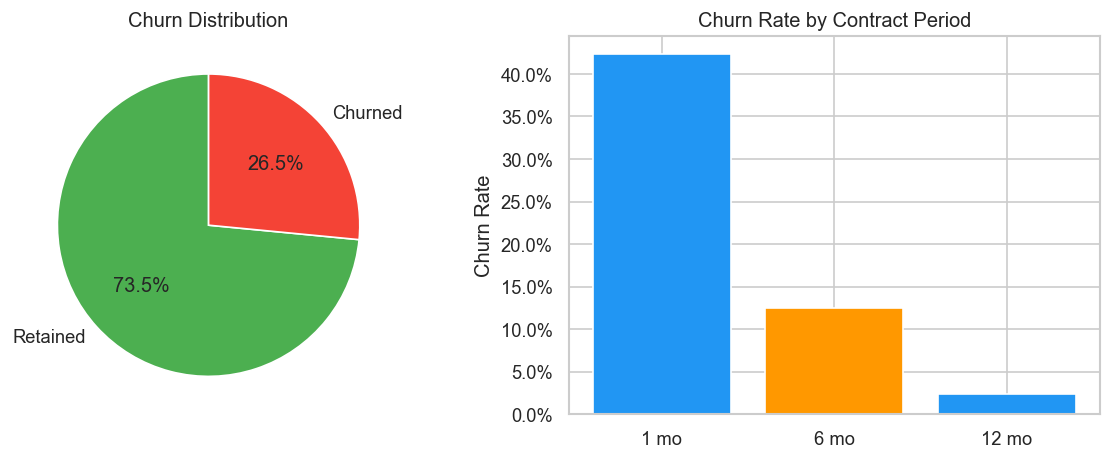

In [5]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[0].set_title('Churn Distribution')

churn_rate = df.groupby('Contract_period')['Churn'].mean().reset_index()
axes[1].bar(churn_rate['Contract_period'].astype(str) + ' mo',
            churn_rate['Churn'], color=['#2196F3', '#FF9800'])
axes[1].set_title('Churn Rate by Contract Period')
axes[1].set_ylabel('Churn Rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

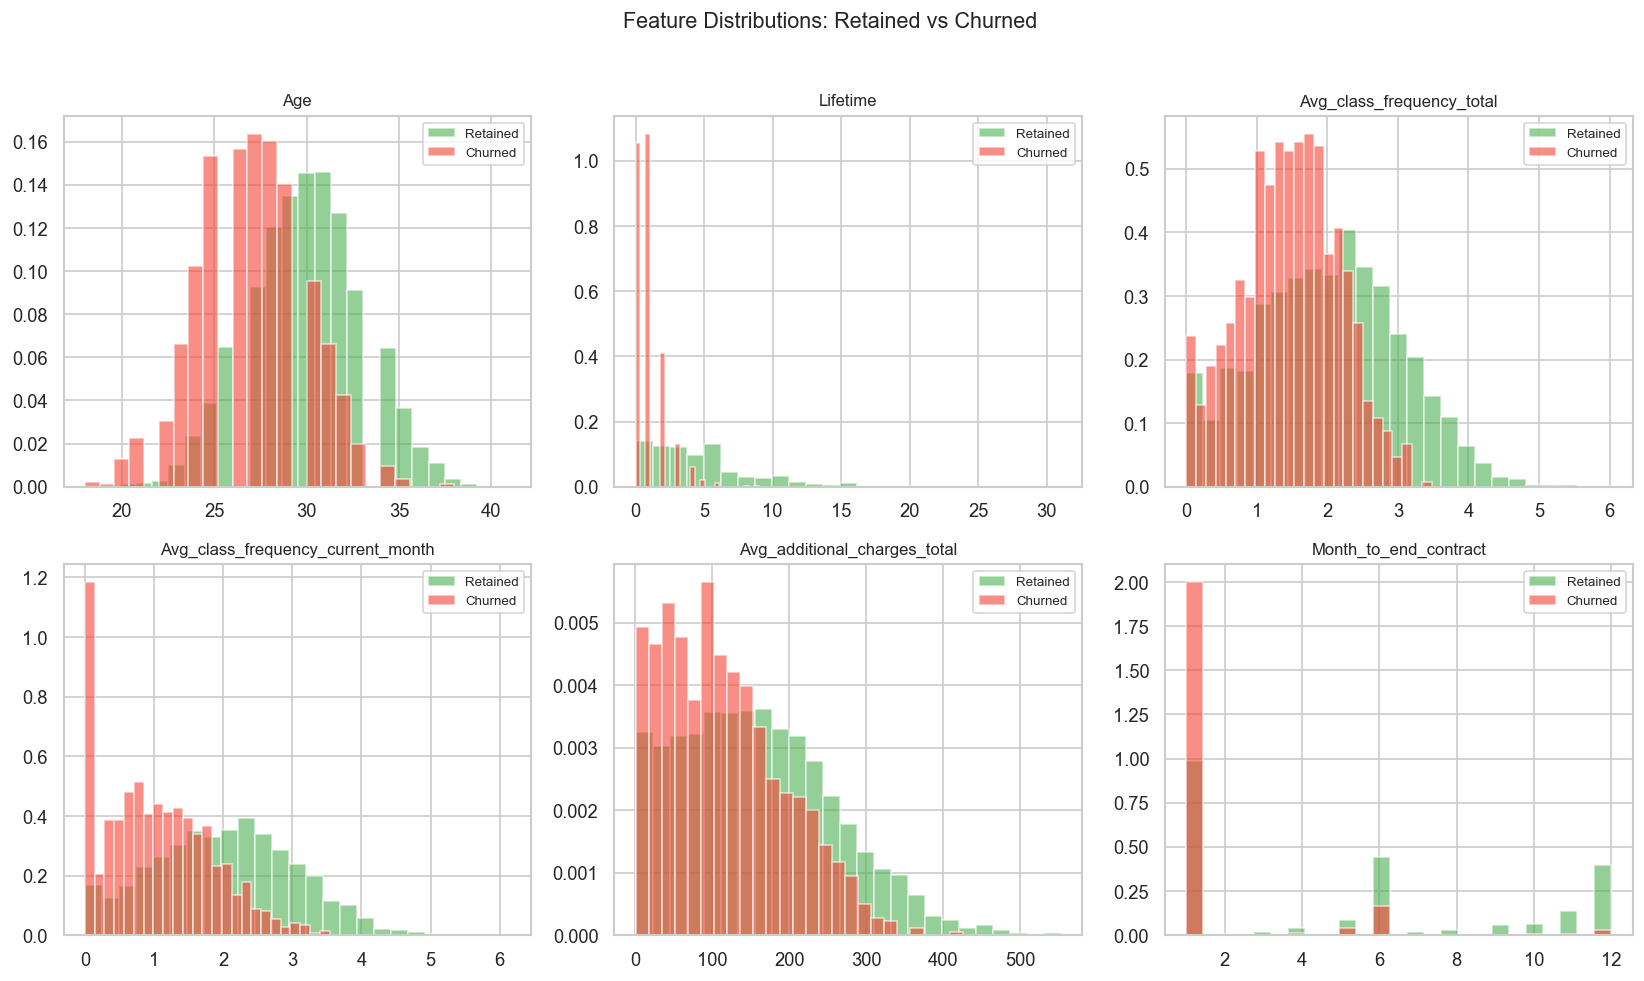

In [6]:
# Feature distributions by churn label
num_cols = ['Age', 'Lifetime', 'Avg_class_frequency_total',
            'Avg_class_frequency_current_month', 'Avg_additional_charges_total',
            'Month_to_end_contract']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, num_cols):
    for label, color in zip([0, 1], ['#4CAF50', '#F44336']):
        ax.hist(df[df['Churn'] == label][col], bins=25,
                alpha=0.6, color=color,
                label='Retained' if label == 0 else 'Churned', density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions: Retained vs Churned', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

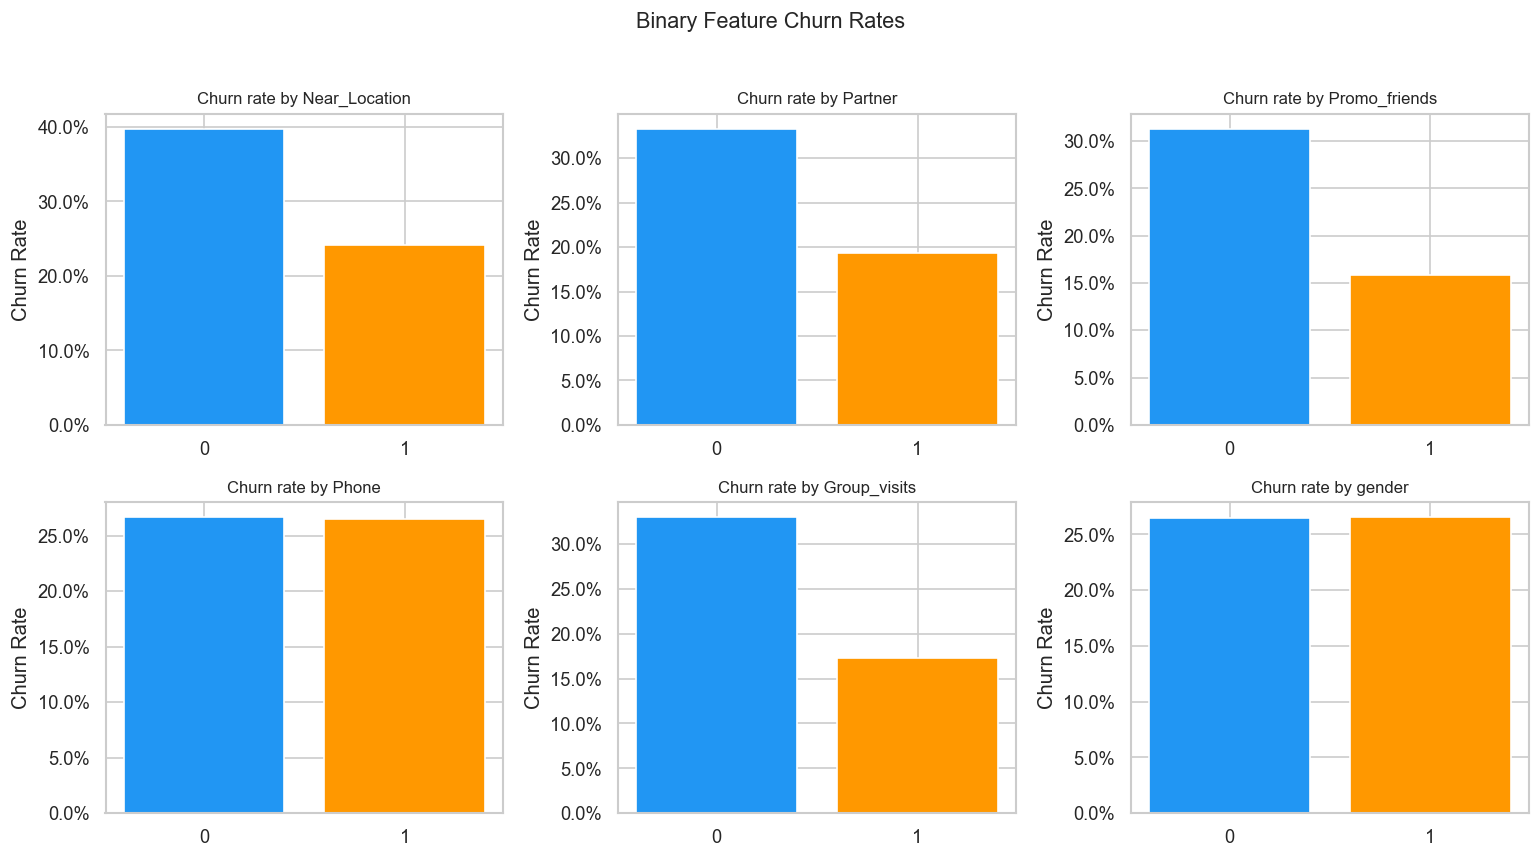

In [7]:
# Binary feature churn rates
bin_cols = ['Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Group_visits', 'gender']
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, bin_cols):
    rates = df.groupby(col)['Churn'].mean()
    ax.bar(rates.index.astype(str), rates.values, color=['#2196F3', '#FF9800'])
    ax.set_title(f'Churn rate by {col}', fontsize=10)
    ax.set_ylabel('Churn Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.suptitle('Binary Feature Churn Rates', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

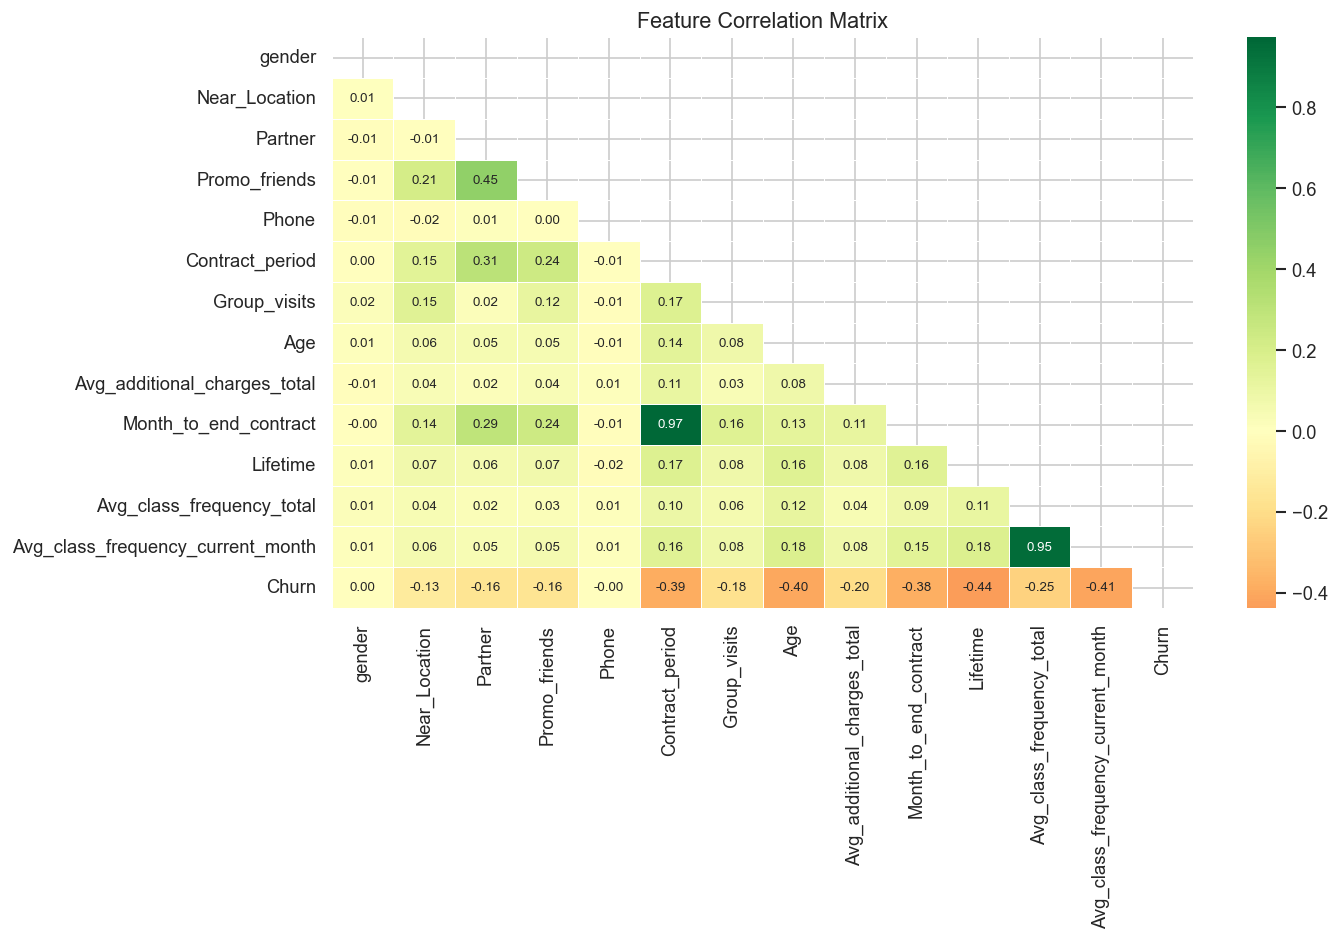

In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [9]:
def engineer_features(df):
    df = df.copy()

    # Ratio of current month visits vs overall avg (captures engagement DROP)
    df['freq_drop_ratio'] = (
        df['Avg_class_frequency_current_month'] /
        (df['Avg_class_frequency_total'] + 1e-5)
    )

    # High engagement flag: visits 3+ times/week on average
    df['high_engagement'] = (df['Avg_class_frequency_total'] >= 3.0).astype(int)

    # Near contract end: most dangerous churn window
    df['near_contract_end'] = (df['Month_to_end_contract'] <= 1).astype(int)

    # Early member: first 2 months — high onboarding churn risk
    df['early_member'] = (df['Lifetime'] <= 2).astype(int)

    return df

df = engineer_features(df)
print(f'Features after engineering: {df.shape[1]} columns')
print('New features:', ['freq_drop_ratio', 'high_engagement', 'near_contract_end', 'early_member'])

Features after engineering: 18 columns
New features: ['freq_drop_ratio', 'high_engagement', 'near_contract_end', 'early_member']


## 4. Preprocessing — Split & Scale

In [10]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Churn rate in train: {y_train.mean():.2%} | test: {y_test.mean():.2%}')

Train: (3200, 17) | Test: (800, 17)
Churn rate in train: 26.53% | test: 26.50%


## 5. Model Training & Cross-Validation

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost':             XGBClassifier(
                               n_estimators=300,
                               learning_rate=0.05,
                               max_depth=5,
                               subsample=0.8,
                               colsample_bytree=0.8,
                               reg_alpha=0.1,
                               reg_lambda=1.0,
                               eval_metric='logloss',
                               random_state=42,
                           ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('5-Fold Stratified CV — ROC-AUC')
print('-' * 45)
for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')
    model.fit(X_train_sc, y_train)

5-Fold Stratified CV — ROC-AUC
---------------------------------------------
Logistic Regression      : 0.9755 ± 0.0046
Random Forest            : 0.9841 ± 0.0026
Gradient Boosting        : 0.9879 ± 0.0023
XGBoost                  : 0.9877 ± 0.0015


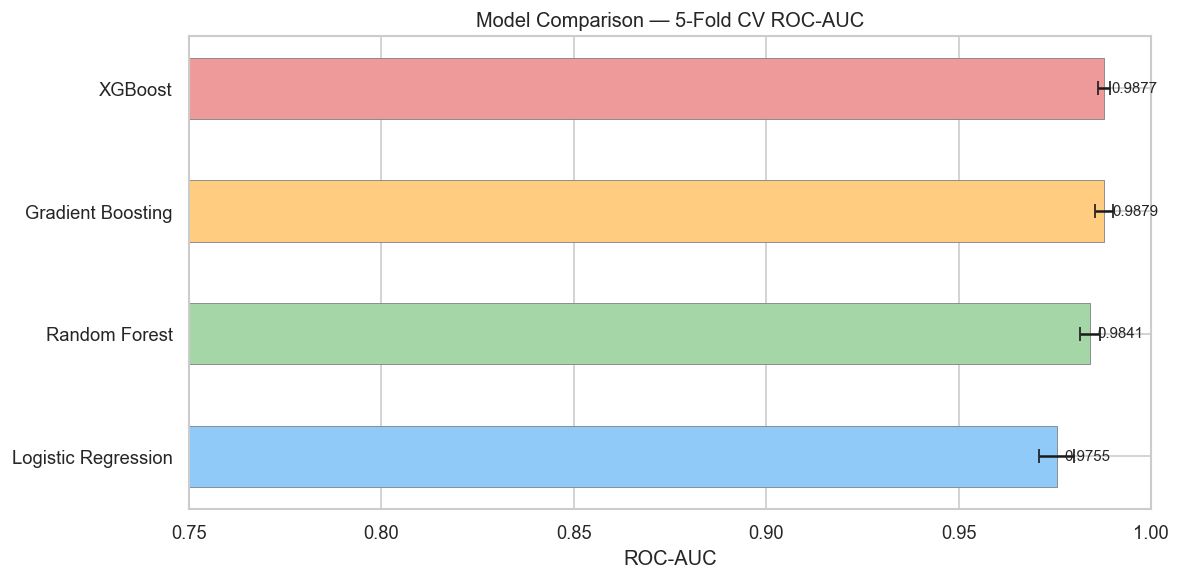

In [12]:
# CV comparison plot
fig, ax = plt.subplots(figsize=(10, 5))
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]
colors = ['#90CAF9', '#A5D6A7', '#FFCC80', '#EF9A9A']
bars = ax.barh(names, means, xerr=stds, color=colors, edgecolor='gray',
               linewidth=0.5, capsize=4, height=0.5)
ax.set_xlabel('ROC-AUC')
ax.set_title('Model Comparison — 5-Fold CV ROC-AUC')
ax.set_xlim(0.75, 1.0)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Evaluate Best Model (XGBoost)

In [13]:
best_model = models['XGBoost']
y_pred  = best_model.predict(X_test_sc)
y_proba = best_model.predict_proba(X_test_sc)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print(f'Test ROC-AUC: {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

Test ROC-AUC: 0.9880

              precision    recall  f1-score   support

    Retained       0.96      0.98      0.97       588
     Churned       0.94      0.90      0.92       212

    accuracy                           0.96       800
   macro avg       0.95      0.94      0.94       800
weighted avg       0.96      0.96      0.96       800



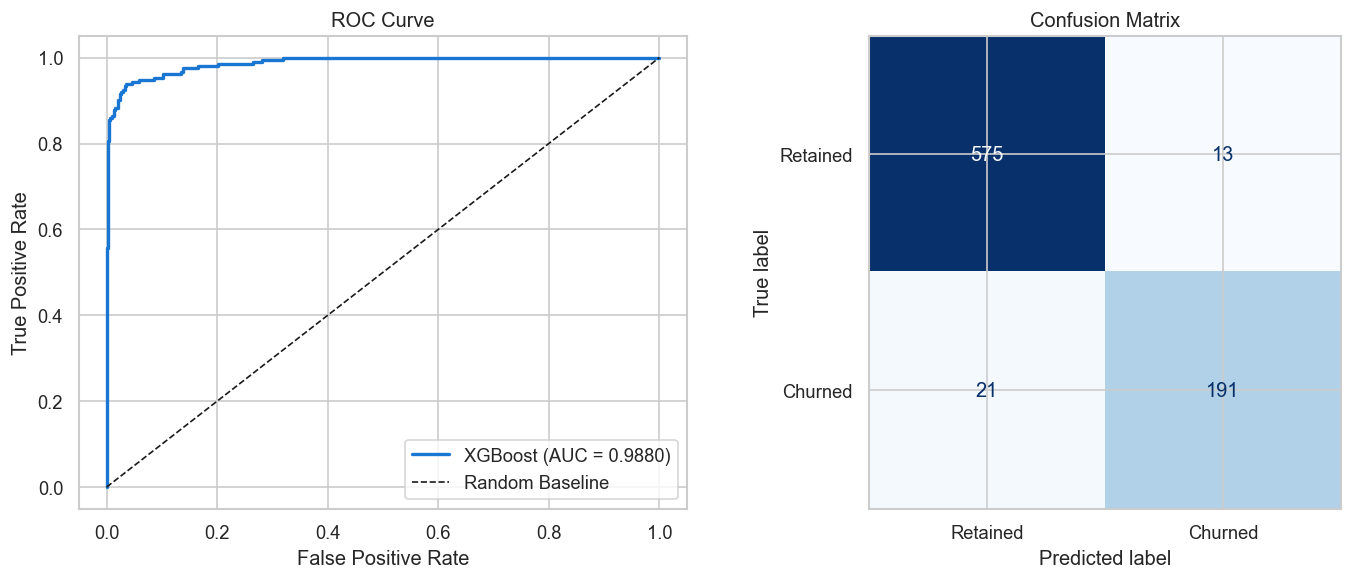

In [14]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color='#1976D2', lw=2, label=f'XGBoost (AUC = {auc:.4f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random Baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

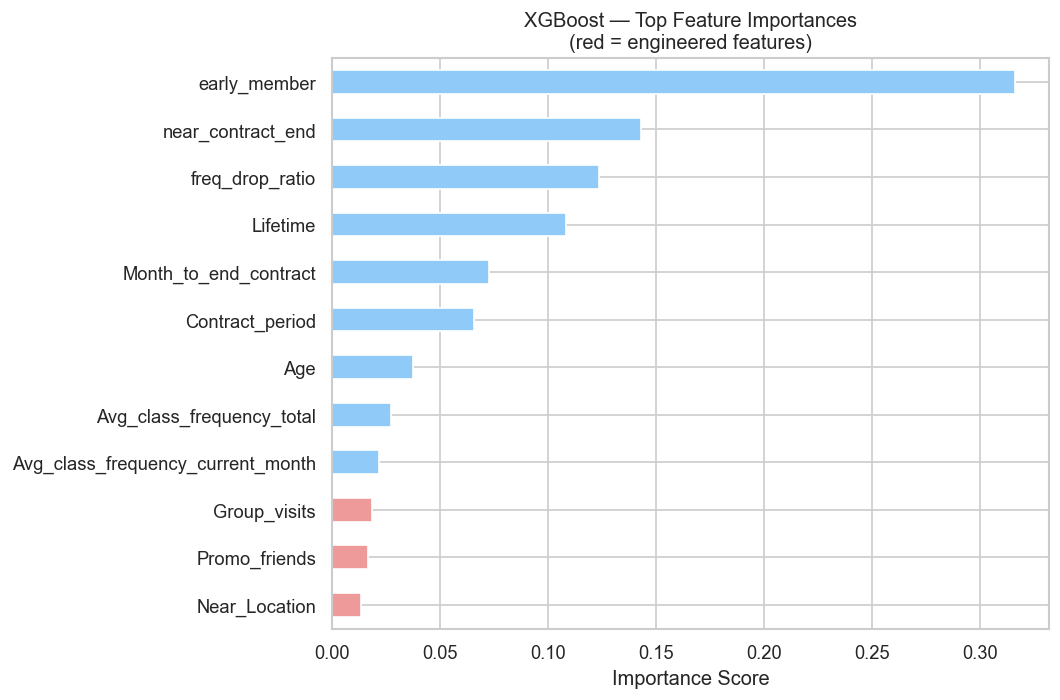

In [15]:
# Feature Importance
fi = pd.Series(best_model.feature_importances_, index=X.columns)
fi_top = fi.nlargest(12)

plt.figure(figsize=(9, 6))
colors_fi = ['#EF9A9A' if f in ['freq_drop_ratio','near_contract_end','high_engagement','early_member']
             else '#90CAF9' for f in fi_top.index]
fi_top.sort_values().plot(kind='barh', color=colors_fi)
plt.xlabel('Importance Score')
plt.title('XGBoost — Top Feature Importances\n(red = engineered features)')
plt.tight_layout()
plt.show()

## 7. Save Artifacts

In [16]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/xgb_model.pkl')
joblib.dump(scaler,     '../models/scaler.pkl')
joblib.dump(list(X.columns), '../models/feature_names.pkl')

metrics = {
    'best_model': 'XGBoost',
    'test_auc': round(float(auc), 4),
    'cv_results': {name: {'mean': round(float(scores.mean()), 4), 'std': round(float(scores.std()), 4)}
                   for name, scores in cv_results.items()},
    'top_features': {k: round(float(v), 4) for k, v in fi.nlargest(10).items()},
    'feature_names': list(X.columns),
}
with open('../models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('✅ Saved: models/xgb_model.pkl')
print('✅ Saved: models/scaler.pkl')
print('✅ Saved: models/feature_names.pkl')
print('✅ Saved: models/metrics.json')

✅ Saved: models/xgb_model.pkl
✅ Saved: models/scaler.pkl
✅ Saved: models/feature_names.pkl
✅ Saved: models/metrics.json


## ✅ Done!
Model artifacts saved. Now start the FastAPI backend:
```bash
cd api && uvicorn main:app --reload
```
Then open the frontend at `frontend/index.html` or run:
```bash
cd frontend && npm install && npm run dev
```